# Historical Pool Data — FinTech 590
Fetches daily historical TVL, APY, and impermanent loss for each pool in `data/top_pools.parquet`.

**Run `defi_pipeline.ipynb` first** to generate the pool list.

Data source: [DeFiLlama Chart API](https://yields.llama.fi/docs) — free, no API key required.  
Coverage: daily data from **March 2022 → present** (~1,400+ data points per pool).

## 0. Imports

In [ ]:
import time, pathlib
import requests
import pandas as pd

POOLS_PARQUET   = pathlib.Path("data/top_pools.parquet")
HISTORY_PARQUET = pathlib.Path("data/pool_history.parquet")
CHART_URL       = "https://yields.llama.fi/chart/"
DELAY           = 1.5    # seconds between requests
RETRY_WAIT      = 60     # seconds to wait after a 403/429 before retrying
MAX_RETRIES     = 2

print("Ready.")

## 1. Load Pool List

In [2]:
pools = pd.read_parquet(POOLS_PARQUET)
print(f"Loaded {len(pools)} pools from {POOLS_PARQUET}")
pools[["chain", "address", "token0", "token1", "fee_tier", "llama_id"]]

Loaded 47 pools from data\top_pools.parquet


,chain,address,token0,token1,fee_tier,llama_id
0,Ethereum,0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640,USDC,WETH,500,665dc8bc-c79d-4800-97f7-304bf368e547
1,Ethereum,0x4e68Ccd3E89f51C3074ca5072bbAC773960dFa36,WETH,USDT,3000,fc9f488e-8183-416f-a61e-4e5c571d4395
2,Ethereum,0x4585FE77225b41b697C938B018E2Ac67Ac5a20c0,WBTC,WETH,500,d59a5728-d391-4989-86f6-a94e11e0eb3b
3,Ethereum,0xCBCdF9626bC03E24f779434178A73a0B4bad62eD,WBTC,WETH,3000,c5599b3a-ea73-4017-a867-72eb971301d1
4,Ethereum,0xe8f7c89C5eFa061e340f2d2F206EC78FD8f7e124,WBTC,CBBTC,100,c0bbcf6c-9454-4773-a19f-c6486484c287
5,Ethereum,0xC5c134A1f112efA96003f8559Dba6fAC0BA77692,WHITE,WETH,100,9be33e76-5f9c-435f-a008-e33965f602d8
6,Ethereum,0x99ac8cA7087fA4A2A1FB6357269965A2014ABc35,WBTC,USDC,3000,bbecbf69-a4f7-43e3-8b72-de180d106e2c
7,Ethereum,0x3416cF6C708Da44DB2624D63ea0AAef7113527C6,USDC,USDT,100,e737d721-f45c-40f0-9793-9f56261862b9
8,Ethereum,0x9Db9e0e53058C89e5B94e29621a205198648425B,WBTC,USDT,3000,2608e751-41d4-47db-9b9c-4bf3a757fc1b
9,Ethereum,0xbAFeAd7c60Ea473758ED6c6021505E8BBd7e8E5d,AUSD,USDC,100,458a64c5-2f64-4ca6-8be7-41b8aef029eb


## 2. Fetch Historical Data

For each pool, calls `yields.llama.fi/chart/{llama_id}` which returns daily snapshots with:

| Field | Description |
|-------|-------------|
| `tvl_usd` | Total value locked (USD) |
| `apy` | Total APY (fees + rewards) |
| `apy_base` | APY from trading fees only |
| `apy_base_7d` | 7-day rolling average base APY |
| `il_7d` | 7-day impermanent loss (%) |

In [ ]:
all_records = []

for _, pool in pools.iterrows():
    label = f"[{pool['chain']}] {pool['token0']}/{pool['token1']} {pool['fee_tier']/1e4:.2f}%"
    print(f"  Fetching {label} ...", end="", flush=True)

    data = []
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = requests.get(CHART_URL + pool["llama_id"], timeout=30)
            if r.status_code in (403, 429):
                if attempt < MAX_RETRIES:
                    print(f"  rate-limited, waiting {RETRY_WAIT}s ...", end="", flush=True)
                    time.sleep(RETRY_WAIT)
                    continue
                else:
                    print(f"  ERROR: {r.status_code} after {MAX_RETRIES} attempts")
                    break
            r.raise_for_status()
            data = r.json().get("data", [])
            break
        except requests.RequestException as e:
            print(f"  ERROR: {e}")
            break

    for point in data:
        all_records.append({
            "address":     pool["address"],
            "chain":       pool["chain"],
            "token0":      pool["token0"],
            "token1":      pool["token1"],
            "fee_tier":    pool["fee_tier"],
            "date":        point["timestamp"][:10],
            "tvl_usd":     point.get("tvlUsd"),
            "apy":         point.get("apy"),
            "apy_base":    point.get("apyBase"),
            "apy_base_7d": point.get("apyBase7d"),
            "il_7d":       point.get("il7d"),
        })

    if data:
        print(f"  {len(data)} days")

    time.sleep(DELAY)

print(f"\nTotal records collected: {len(all_records):,}")

## 3. Save to Parquet

In [4]:
df = pd.DataFrame(all_records)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["chain", "address", "date"]).reset_index(drop=True)

df.to_parquet(HISTORY_PARQUET, index=False, engine="pyarrow")

print(f"Saved {len(df):,} rows to {HISTORY_PARQUET}")
print(f"Date range : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Pools      : {df['address'].nunique()} addresses across {df['chain'].nunique()} chains")
print()
df.head(10)

Saved 2,958 rows to data\pool_history.parquet
Date range : 2022-03-27  →  2026-03-26
Pools      : 4 addresses across 3 chains



,address,chain,token0,token1,fee_tier,date,tvl_usd,apy,apy_base,apy_base_7d,il_7d
0,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-03-27,2805457,4.77445,4.77445,NaN,NaN
1,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-03-28,2832743,4.38523,4.38523,NaN,NaN
2,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-03-29,2822630,5.56906,5.56906,NaN,NaN
3,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-03-30,2851291,3.45863,3.45863,NaN,NaN
4,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-03-31,2504121,5.11012,5.11012,NaN,NaN
5,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-04-01,2572690,6.08950,6.08950,NaN,NaN
6,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-04-02,2608247,10.83666,10.83666,NaN,NaN
7,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-04-03,2666703,3.51785,3.51785,NaN,NaN
8,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-04-04,2641332,3.94093,3.94093,NaN,NaN
9,0x2f5e87C9312fa29aed5c179E456625D79015299c,Arbitrum,WBTC,WETH,500,2022-04-05,2596518,2.81361,2.81361,NaN,NaN


## 4. Quick Sanity Checks

In [5]:
# Records per pool
print("Days of history per pool:")
summary = (
    df.groupby(["chain", "token0", "token1", "fee_tier"])
    .agg(days=("date", "count"), earliest=("date", "min"), latest=("date", "max"))
    .reset_index()
)
summary["fee_pct"] = summary["fee_tier"] / 1e4
summary.drop(columns="fee_tier", inplace=True)
print(summary.to_string(index=False))

Days of history per pool:
   chain token0 token1  days   earliest     latest  fee_pct
Arbitrum   WBTC   WETH  1397 2022-03-27 2026-03-26     0.05
    Base    MPP   USDC    23 2026-02-27 2026-03-26     0.30
Ethereum   AUSD   USDC   105 2025-04-11 2026-03-26     0.01
Ethereum   WBTC   USDC  1433 2022-03-27 2026-03-26     0.30


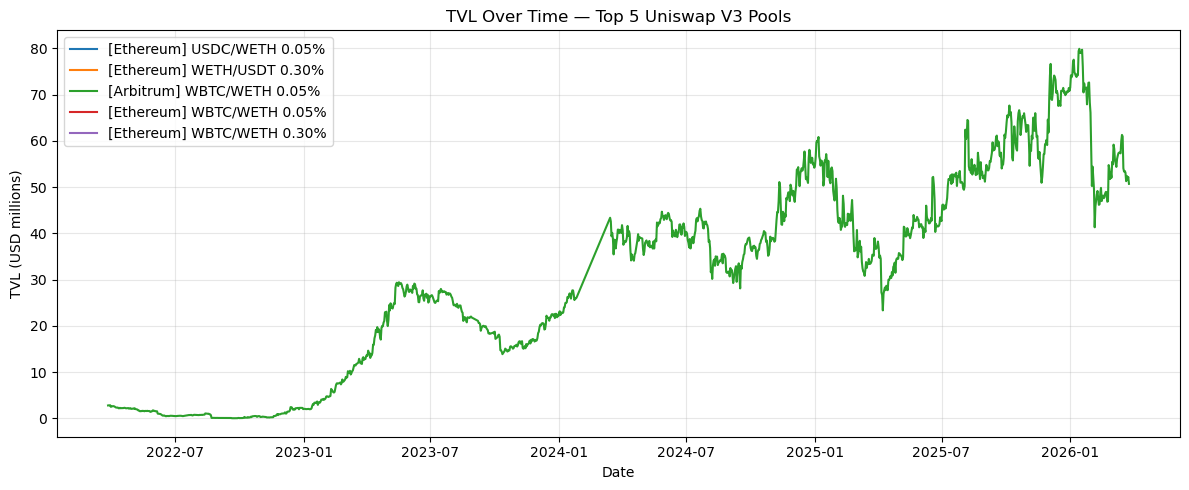

Chart saved to data/tvl_history.png


In [6]:
# TVL over time for top 5 pools by current TVL
import matplotlib.pyplot as plt

top5 = pools.nlargest(5, "tvl_usd")[["address", "chain"]].values.tolist()
fig, ax = plt.subplots(figsize=(12, 5))

for addr, chain in top5:
    subset = df[(df["address"] == addr) & (df["chain"] == chain)]
    row    = pools[(pools["address"] == addr) & (pools["chain"] == chain)].iloc[0]
    label  = f"[{row['chain']}] {row['token0']}/{row['token1']} {row['fee_tier']/1e4:.2f}%"
    ax.plot(subset["date"], subset["tvl_usd"] / 1e6, label=label)

ax.set_title("TVL Over Time — Top 5 Uniswap V3 Pools")
ax.set_ylabel("TVL (USD millions)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/tvl_history.png", dpi=150)
plt.show()
print("Chart saved to data/tvl_history.png")